1. Install Dependencies

In [1]:
!pip install yfinance matplotlib scikit-learn torch torchinfo


2. Data Acquisition/Generation (Stock Example)

In [2]:
import yfinance as yf
import pandas as pd

# Download multi-variate (e.g., 'AAPL', 'GOOGL', 'MSFT') stock data
tickers = ['AAPL', 'GOOGL', 'MSFT']
df = yf.download(tickers, start="2020-01-01", end="2024-12-31")['Close'].dropna()
print(df.head())
df.to_csv("multi_stock_data.csv")


/tmp/ipython-input-3433556433.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start="2020-01-01", end="2024-12-31")['Close'].dropna()
[*********************100%***********************]  3 of 3 completed

Ticker           AAPL      GOOGL        MSFT
Date                                        
2020-01-02  72.468269  67.965225  152.505661
2020-01-03  71.763718  67.609680  150.606750
2020-01-06  72.335571  69.411766  150.996033
2020-01-07  71.995361  69.277687  149.619278
2020-01-08  73.153511  69.770782  152.002426


3. Data Preprocessing

In [3]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df.values)

def create_sequences(data, seq_len=30):
    X, y = [], []
    for i in range(len(data)-seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

seq_len = 30  # Number of past steps to use
X, y = create_sequences(scaled_data, seq_len)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (981, 30, 3) Test shape: (246, 30, 3)


4. Classical ML Baselines (Prophet, SARIMA, Simple LSTM)

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

class LSTM(nn.Module):
    def __init__(self, n_features, hidden_dim=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, n_features)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.fc(lstm_out[:, -1])
        return out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
n_features = X.shape[2]
model_lstm = LSTM(n_features=n_features).to(device)

loader = DataLoader(TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).float()), batch_size=64, shuffle=True)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.001)

# Training loop
for epoch in range(20):  # Tuning required
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model_lstm(xb), yb)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch}, Loss {loss.item()}")


Epoch 0, Loss 0.03439551964402199
Epoch 1, Loss 0.01937742903828621
Epoch 2, Loss 0.0071781654842197895
Epoch 3, Loss 0.004944293759763241
Epoch 4, Loss 0.003790109883993864
Epoch 5, Loss 0.0029149921610951424
Epoch 6, Loss 0.003173538250848651
Epoch 7, Loss 0.00268670660443604
Epoch 8, Loss 0.003479389939457178
Epoch 9, Loss 0.0027383153792470694
Epoch 10, Loss 0.00230757356621325
Epoch 11, Loss 0.0019678135868161917
Epoch 12, Loss 0.0020926115103065968
Epoch 13, Loss 0.0017176412511616945
Epoch 14, Loss 0.0019346532644703984
Epoch 15, Loss 0.0023314564023166895
Epoch 16, Loss 0.0019148201681673527
Epoch 17, Loss 0.001569582847878337
Epoch 18, Loss 0.0009079758892767131
Epoch 19, Loss 0.0010716557735577226


5. Attention-Based Deep Learning Model

In [5]:
class AttentionLSTM(nn.Module):
    def __init__(self, n_features, hidden_dim=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden_dim, num_layers, batch_first=True)
        self.attn = nn.Linear(hidden_dim, 1)
        self.fc = nn.Linear(hidden_dim, n_features)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        attn_weights = torch.softmax(self.attn(lstm_out), dim=1)
        attn_applied = torch.sum(lstm_out * attn_weights, dim=1)
        out = self.fc(attn_applied)
        return out, attn_weights

model_attn = AttentionLSTM(n_features=n_features).to(device)
optimizer_attn = torch.optim.AdamW(model_attn.parameters(), lr=0.001)

# Training with attention (tuning and CV can be added)
for epoch in range(20):  # Tune as needed
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer_attn.zero_grad()
        out, attn_weights = model_attn(xb)
        loss = loss_fn(out, yb)
        loss.backward()
        optimizer_attn.step()
    print(f"Attention Epoch {epoch}, Loss {loss.item()}")


Attention Epoch 0, Loss 0.026715466752648354
Attention Epoch 1, Loss 0.018241500481963158
Attention Epoch 2, Loss 0.013429856859147549
Attention Epoch 3, Loss 0.004881063476204872
Attention Epoch 4, Loss 0.0045539517886936665
Attention Epoch 5, Loss 0.0031526500824838877
Attention Epoch 6, Loss 0.0033717502374202013
Attention Epoch 7, Loss 0.00373741053044796
Attention Epoch 8, Loss 0.003640241688117385
Attention Epoch 9, Loss 0.002701542107388377
Attention Epoch 10, Loss 0.00398097513243556
Attention Epoch 11, Loss 0.003442782675847411
Attention Epoch 12, Loss 0.0023753808345645666
Attention Epoch 13, Loss 0.0025363739114254713
Attention Epoch 14, Loss 0.0021685948595404625
Attention Epoch 15, Loss 0.002510926453396678
Attention Epoch 16, Loss 0.0024407068267464638
Attention Epoch 17, Loss 0.001667099422775209
Attention Epoch 18, Loss 0.0015572726260870695
Attention Epoch 19, Loss 0.001884924597106874


6. Performance Metrics and Visualization

RMSE: 18.966060447248893, MAE: 15.477816119103574, MAPE: 6.2777105692788355


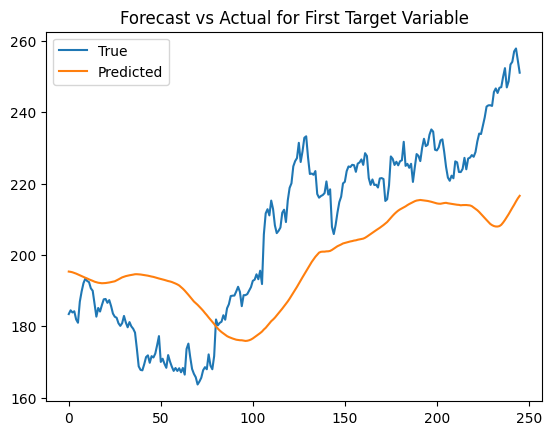

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

def inverse_transform(scaled):
    return scaler.inverse_transform(scaled)

with torch.no_grad():
    y_pred, _ = model_attn(torch.tensor(X_test).float().to(device))
    y_pred = y_pred.cpu().numpy()
    y_true = y_test
    y_pred_inv = inverse_transform(y_pred)
    y_true_inv = inverse_transform(y_true)
    rmse = np.sqrt(mean_squared_error(y_true_inv, y_pred_inv))
    mae = mean_absolute_error(y_true_inv, y_pred_inv)
    mape = np.mean(np.abs((y_true_inv - y_pred_inv) / y_true_inv)) * 100

print(f"RMSE: {rmse}, MAE: {mae}, MAPE: {mape}")

plt.plot(y_true_inv[:, 0], label='True')
plt.plot(y_pred_inv[:, 0], label='Predicted')
plt.legend()
plt.title("Forecast vs Actual for First Target Variable")
plt.show()


7. Attention Weights Analysis

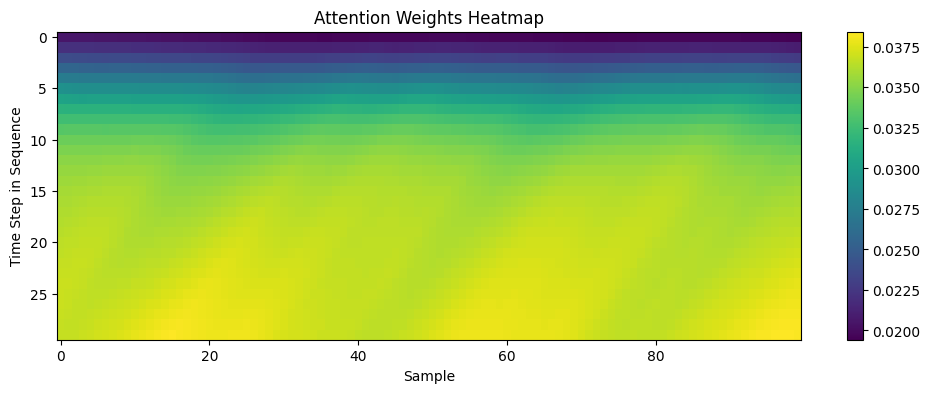

In [7]:
with torch.no_grad():
    _, attn_weights_val = model_attn(torch.tensor(X_test[:100]).float().to(device))
    attn_weights_val = attn_weights_val.squeeze(-1).cpu().numpy()
plt.figure(figsize=(12,4))
plt.imshow(attn_weights_val.T, aspect='auto', cmap='viridis')
plt.xlabel("Sample")
plt.ylabel("Time Step in Sequence")
plt.title("Attention Weights Heatmap")
plt.colorbar()
plt.show()
